# 02 — Customer Analysis: Who Are Tang's Customers?

**Goal:** a descriptive, single-pass look at customer behavior using the cleaned 2024+ order data from notebook 01 — visit frequency, spend patterns, and time-based patterns. This notebook is purely descriptive: no revenue-recovery framing, no recommendations, just "what does the data show."

**Privacy note (this repo is public):** this notebook works with individual customer phone numbers (`customerID`) for grouping, but never prints a raw phone number anywhere. Every output below is an aggregate — a count, a percentage, a distribution — never a table with a customer identifier attached to it.

**Scope note:** notebook 01 found that only 71.8% of clean orders have a `customerID` worth trusting for customer-level grouping (the rest are either missing entirely or belong to a systemic-default phone cluster). Every analysis below that groups by customer filters to `cid_usable=True` first. Analyses that don't need customer identity (time-of-day patterns, revenue trends) use the full clean dataset instead, since CID quality doesn't matter for those and there's no reason to throw away data unnecessarily.


## Setup

Loading `pandas` for the data work, `matplotlib` for charts, and `pathlib` just to build a clean path to the CSV. We also fix a consistent chart style once here (colors, muted gridlines, no chart border) so every chart below looks like it belongs to the same notebook instead of using matplotlib's defaults.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# a small, fixed color palette used consistently across every chart in this notebook --
# blue for the "highlighted" series, green as the second categorical color, muted grays
# for baselines/de-emphasized data, and a 4-step blue ramp for the ordinal visit tiers
BLUE = "#2a78d6"
GREEN = "#008300"
GRAY_BASELINE = "#c3c2b7"
GRAY_MUTED = "#898781"
GRID_COLOR = "#e1e0d9"
TEXT_SECONDARY = "#52514e"
TIER_RAMP = ["#86b6ef", "#5598e7", "#2a78d6", "#184f95"]  # light -> dark, one-time -> frequent

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": GRID_COLOR,
    "axes.grid": True,
    "grid.color": GRID_COLOR,
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "font.size": 10,
    "text.color": "#0b0b0b",
    "axes.labelcolor": TEXT_SECONDARY,
    "xtick.color": TEXT_SECONDARY,
    "ytick.color": TEXT_SECONDARY,
})


## Load the clean data

Loading `data/cleaned_orders_2024plus.csv` directly, since notebook 01 already did all the SQL Server connection work and data-quality auditing — no reason to repeat it. We parse `checkinTime` as a real datetime up front since almost every analysis below needs to group by day/hour/month.


In [2]:
orders = pd.read_csv(Path("..") / "data" / "cleaned_orders_2024plus.csv", parse_dates=["checkinTime"])

print(f"Loaded {len(orders):,} clean orders")
print(f"Date range: {orders['checkinTime'].min().date()} to {orders['checkinTime'].max().date()}")


Loaded 50,069 clean orders
Date range: 2024-01-01 to 2026-06-09


**Note:** the data runs through early June 2026, so the most recent month is partial (only ~9 days of data). Any chart below that shows a trend by month excludes or clearly marks that partial month — otherwise it would look like a steep, fake drop-off at the very end.

## Scope: how much of the data can we actually say is "a customer"?

This is the first thing a reader needs to see before any customer-level finding below: this analysis does **not** cover 100% of order volume. Only orders with a trustworthy `customerID` (`cid_usable=True`) can be grouped into "this is one customer's visits" — the rest either have no CID at all or belong to the systemic-default phone cluster identified in notebook 01.


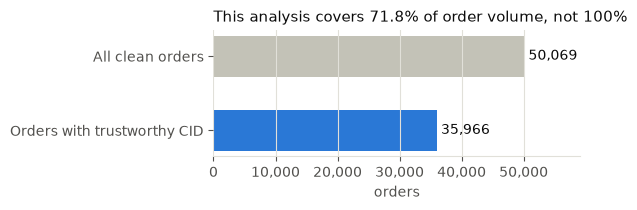

35,966 of 50,069 clean orders (71.8%) have a customer ID worth grouping by.


In [3]:
n_total = len(orders)
n_usable = int(orders["cid_usable"].sum())
pct_usable = 100 * n_usable / n_total

fig, ax = plt.subplots(figsize=(6, 2.2))
bars = ax.barh(
    ["Orders with trustworthy CID", "All clean orders"],
    [n_usable, n_total],
    color=[BLUE, GRAY_BASELINE],
    height=0.55,
)
for bar, value in zip(bars, [n_usable, n_total]):
    ax.text(value + 700, bar.get_y() + bar.get_height() / 2, f"{value:,}",
            va="center", ha="left", fontsize=10, color="#0b0b0b")

ax.set_xlim(0, n_total * 1.18)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_xlabel("orders")
ax.set_title(f"This analysis covers {pct_usable:.1f}% of order volume, not 100%", loc="left", fontsize=11)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

print(f"{n_usable:,} of {n_total:,} clean orders ({pct_usable:.1f}%) have a customer ID worth grouping by.")


## 🚩 A data anomaly found while exploring, before we go further

Before building any per-customer metrics, it's worth sanity-checking who the *most frequent* "customers" actually are — an easy way to catch a leftover data-quality issue that notebook 01's audit didn't specifically test for.

Notebook 01 already established Tang's real phone number as a known fact (confirmed separately, not shown here) to prove it was *not* the systemic-default cluster. But "not part of that cluster" only means it's a real, complete, correctly-formatted phone number — it doesn't mean it's a customer. It's the restaurant's **own** number, and it still passes the `cid_usable` check because nothing in notebook 01's audit was designed to catch "a real, validly-formatted number that happens to belong to the business itself." Checking the single highest-frequency "customer" confirms this: over 150 visits spanning the entire two-and-a-half-year window, 97% under one `orderType` code, mostly cash — a usage pattern that looks like internal/staff activity, not a walk-in diner.

**Judgment call:** rather than leave this in as if it were a real loyal customer (which would make it *the* top "customer" in every ranking below), this notebook excludes it from customer-level analysis specifically, the same way notebook 01 excluded the systemic-default cluster. It's a single, already-confirmed value — not a new pattern-based rule — so the impact is tiny (1 record out of 7,805 customers) but the distortion it would otherwise cause at the top of the frequency distribution is not. Flagging this explicitly rather than deciding it silently: **if you know of other numbers that might be internal/staff/vendor lines rather than real customers, this is exactly the kind of thing worth checking for before trusting any "top customer" finding.**

(Following notebook 01's convention: even though this is the restaurant's own business number rather than a customer's, the raw digits still don't get written into this notebook's source. The exclusion below matches on the same masked form notebook 01 displayed.)


In [4]:
def _masked_form(value):
    """Same masking scheme as notebook 01 (area code + last 4 visible, exchange hidden) --
    used here only to match Tang's own number without writing its raw digits in this notebook."""
    if not isinstance(value, str) or len(value) < 13 or value[0] != "(":
        return value
    return f"({value[1:4]}) XXX-{value[9:13]}"


TANGS_OWN_CID_MASKED = "(631) XXX-9196"  # matches the masked value shown in notebook 01

customers = orders[
    orders["cid_usable"] & (orders["customerID"].map(_masked_form) != TANGS_OWN_CID_MASKED)
].copy()

n_customer_orders = len(customers)
n_distinct_customers = customers["customerID"].nunique()

print(f"Customer-level analysis population: {n_customer_orders:,} orders "
      f"({100 * n_customer_orders / n_total:.1f}% of all clean orders)")
print(f"Distinct customers: {n_distinct_customers:,}")


Customer-level analysis population: 35,812 orders (71.5% of all clean orders)
Distinct customers: 7,803


## Visit frequency: how often do customers actually come back?

We count orders per distinct `customerID` to get a visits-per-customer distribution, then look at its shape before picking tier boundaries — better to let the actual distribution (quartiles, percentiles) suggest natural breakpoints than to guess round numbers first and check later.


In [5]:
# visits_per_customer has customerID as its index -- kept purely internal, never displayed
visits_per_customer = customers.groupby("customerID").size()

print("Visit-count distribution across distinct customers:")
print(visits_per_customer.describe().round(1))
print()
for p in [50, 75, 90, 95, 99]:
    print(f"  p{p}: {visits_per_customer.quantile(p / 100):.0f} visits")


Visit-count distribution across distinct customers:
count    7803.0
mean        4.6
std         9.1
min         1.0
25%         1.0
50%         1.0
75%         4.0
max       151.0
dtype: float64

  p50: 1 visits
  p75: 4 visits
  p90: 12 visits
  p95: 20 visits
  p99: 45 visits


The distribution is heavily right-skewed (median 1 visit, but a max over 100) — typical for restaurant visit data. The quartile/percentile breaks line up naturally into four tiers:

- **One-time** — exactly 1 visit (the median customer)
- **Occasional** — 2 to 4 visits (up to roughly the 75th percentile)
- **Regular** — 5 to 11 visits (up to roughly the 90th percentile)
- **Frequent** — 12+ visits (the top decile)

These boundaries come directly from the data's own quartiles rather than an arbitrary round-number guess.


In [6]:
def visit_tier(n_visits):
    if n_visits == 1:
        return "One-time"
    if n_visits <= 4:
        return "Occasional"
    if n_visits <= 11:
        return "Regular"
    return "Frequent"


tier_order = ["One-time", "Occasional", "Regular", "Frequent"]
tier_by_customer = visits_per_customer.map(visit_tier)
customers["tier"] = customers["customerID"].map(tier_by_customer)

# revenue-bearing orders only (drop the 366 zero-paid comps for any $-based metric)
customer_revenue_orders = customers[~customers["excluded_from_revenue"]]

summary = pd.DataFrame({
    "n_customers": tier_by_customer.value_counts(),
}).reindex(tier_order)
summary["pct_customers"] = (100 * summary["n_customers"] / summary["n_customers"].sum()).round(1)

orders_by_tier = customers.groupby("tier").size().reindex(tier_order)
summary["n_orders"] = orders_by_tier
summary["pct_orders"] = (100 * orders_by_tier / orders_by_tier.sum()).round(1)

revenue_by_tier = customer_revenue_orders.groupby("tier")["paidAmount"].sum().reindex(tier_order)
summary["revenue"] = revenue_by_tier.round(0)
summary["pct_revenue"] = (100 * revenue_by_tier / revenue_by_tier.sum()).round(1)

avg_ticket_by_tier = customer_revenue_orders.groupby("tier")["paidAmount"].mean().reindex(tier_order)
summary["avg_ticket"] = avg_ticket_by_tier.round(2)

summary


,n_customers,pct_customers,n_orders,pct_orders,revenue,pct_revenue,avg_ticket
One-time,4351,55.8,4351,12.1,168412.0,12.7,39.02
Occasional,1743,22.3,4599,12.8,172919.0,13.0,37.66
Regular,910,11.7,6619,18.5,243222.0,18.3,36.75
Frequent,799,10.2,20243,56.5,742640.0,56.0,36.70


The table above already hints at a concentration story — let's make it visible. For each tier, we plot two bars side by side: what share of *customers* fall in that tier, versus what share of *revenue* they generate. If the bars matched, revenue would track customer count evenly across tiers; a gap shows concentration.


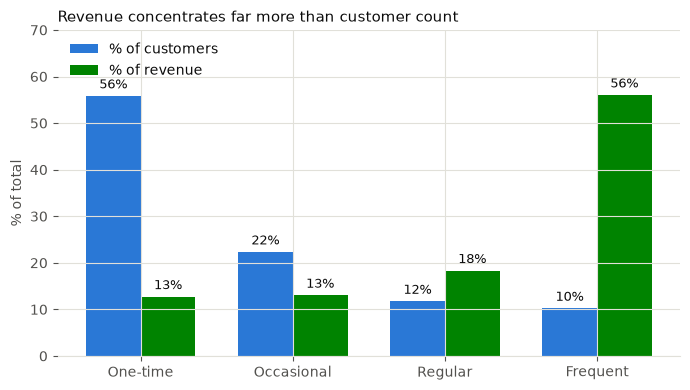

In [7]:
import numpy as np

x = np.arange(len(tier_order))
width = 0.36

fig, ax = plt.subplots(figsize=(7, 4))
b1 = ax.bar(x - width / 2, summary["pct_customers"], width, label="% of customers", color=BLUE)
b2 = ax.bar(x + width / 2, summary["pct_revenue"], width, label="% of revenue", color=GREEN)

for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 1, f"{h:.0f}%",
                ha="center", va="bottom", fontsize=9, color="#0b0b0b")

ax.set_xticks(x)
ax.set_xticklabels(tier_order)
ax.set_ylabel("% of total")
ax.set_ylim(0, max(summary["pct_customers"].max(), summary["pct_revenue"].max()) * 1.25)
ax.set_title("Revenue concentrates far more than customer count", loc="left", fontsize=11)
ax.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()


## Spend patterns

Two questions here: what does a typical ticket look like (the distribution, not just the average — averages hide skew), and does ticket size change with how often someone visits? This uses the **full clean dataset** (all 50,069 orders, not just the customer-identified 71.8%) since ticket size doesn't depend on knowing who the customer is — only `excluded_from_revenue` needs filtering out, per notebook 01's guidance.


In [8]:
revenue_orders = orders[~orders["excluded_from_revenue"]]
paid = revenue_orders["paidAmount"]

print(paid.describe().round(2))
print()
print(f"99th percentile: ${paid.quantile(0.99):.2f}   max: ${paid.max():.2f}")
print(f"Orders over $300 (likely large parties / catering): {(paid > 300).sum()}")


count    49703.00
mean        35.08
std         24.66
min          1.09
25%         19.44
50%         29.80
75%         44.48
max       1228.22
Name: paidAmount, dtype: float64

99th percentile: $110.58   max: $1228.22
Orders over $300 (likely large parties / catering): 17


Median ticket (~$30) sitting well below the mean (~$35) confirms the right-skew — a small number of large orders pull the average up. We cap the histogram's x-axis at $150 (above the 99th percentile) so the shape of the *typical* ticket isn't squashed by a handful of $300+ outliers; those 17 large orders are noted above rather than hidden.


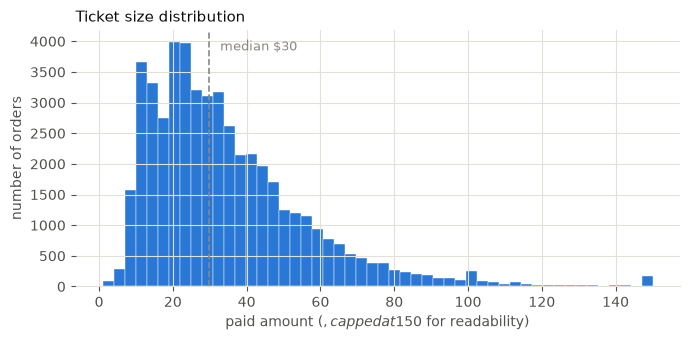

In [9]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(paid.clip(upper=150), bins=50, color=BLUE, edgecolor="white", linewidth=0.3)
ax.axvline(paid.median(), color=GRAY_MUTED, linestyle="--", linewidth=1.2)
ax.text(paid.median() + 3, ax.get_ylim()[1] * 0.92, f"median ${paid.median():.0f}",
        color=GRAY_MUTED, fontsize=9)

ax.set_xlabel("paid amount ($, capped at $150 for readability)")
ax.set_ylabel("number of orders")
ax.set_title("Ticket size distribution", loc="left", fontsize=11)
plt.tight_layout()
plt.show()


Now back to the customer-identified population: does spending more often correlate with spending more *per visit*? A natural assumption is "yes, regulars are bigger spenders" — worth checking rather than assuming.


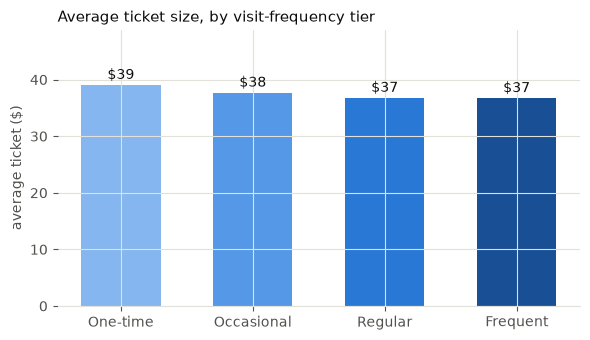

In [10]:
fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.bar(tier_order, summary["avg_ticket"], color=TIER_RAMP, width=0.6)
for bar, value in zip(bars, summary["avg_ticket"]):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.5, f"${value:.0f}",
            ha="center", va="bottom", fontsize=10, color="#0b0b0b")

ax.set_ylabel("average ticket ($)")
ax.set_ylim(0, summary["avg_ticket"].max() * 1.25)
ax.set_title("Average ticket size, by visit-frequency tier", loc="left", fontsize=11)
plt.tight_layout()
plt.show()


**Not what the "regulars spend more" assumption predicts.** Average ticket is essentially flat across tiers (~$37-39), if anything drifting slightly *down* for the most frequent visitors. Revenue concentration in the Frequent tier (from the chart above) is coming entirely from *how often* they visit, not from spending more per visit. Worth treating as a real pattern rather than noise — the gap between tiers is small (a few dollars) but consistent in direction.


## Time-based patterns

### Day of week

Tang is closed Mondays, so this doubles as a sanity check on the data itself before we look for real patterns: if a meaningful chunk of "Monday" orders showed up, that would suggest a `checkinTime` logging issue worth investigating. We use the full clean dataset here again — no customer identity needed.


In [11]:
orders["dow"] = orders["checkinTime"].dt.day_name()
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_counts = orders["dow"].value_counts().reindex(dow_order)

monday_orders = orders[orders["dow"] == "Monday"]
monday_dates = monday_orders["checkinTime"].dt.date.value_counts().sort_index()

print(f"Monday orders: {len(monday_orders)} total, spread across {len(monday_dates)} distinct date(s):")
print(monday_dates)


Monday orders: 68 total, spread across 2 distinct date(s):
checkinTime
2024-01-01    67
2025-02-10     1
Name: count, dtype: int64


**🚩 Anomaly, not a pattern:** 67 of the 68 Monday orders fall on a single date — January 1, 2024, which is a Monday and also New Year's Day, a plausible holiday-exception opening. The one remaining Monday order (February 10, 2025) is an isolated single record with no obvious explanation from this data alone (private event? data entry quirk?) — not enough to draw a conclusion from, just noting it exists. Out of 128 Mondays in the full date range, 126 have zero orders. **The Monday closure is confirmed real**, and the chart below drops Monday to avoid a misleading near-zero bar sitting next to six real operating days.


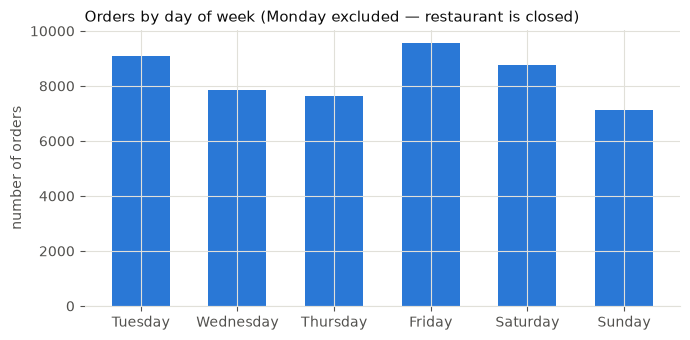

In [12]:
operating_days = [d for d in dow_order if d != "Monday"]
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(operating_days, dow_counts[operating_days], color=BLUE, width=0.6)
ax.set_ylabel("number of orders")
ax.set_title("Orders by day of week (Monday excluded — restaurant is closed)", loc="left", fontsize=11)
plt.tight_layout()
plt.show()


### Time of day

`checkinTime`'s hour component shows when during the day orders come in — useful for seeing whether Tang runs more of a lunch, dinner, or all-day pattern.


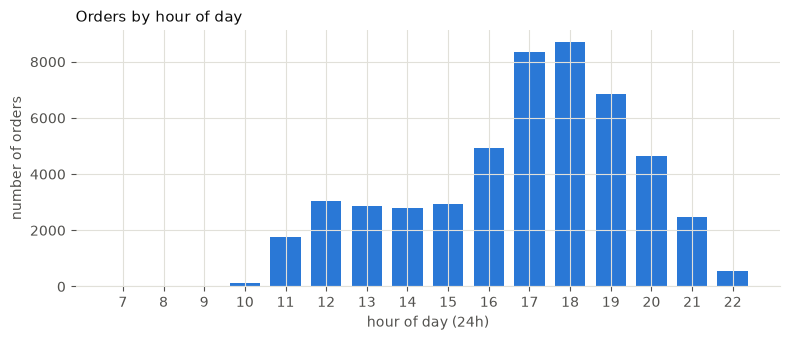

11am-2:59pm (lunch window): 10,455 orders (20.9%)
4pm-9:59pm (dinner window): 35,970 orders (71.8%)


In [13]:
orders["hour"] = orders["checkinTime"].dt.hour
hourly = orders["hour"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(hourly.index, hourly.values, color=BLUE, width=0.75)
ax.set_xlabel("hour of day (24h)")
ax.set_ylabel("number of orders")
ax.set_xticks(range(hourly.index.min(), hourly.index.max() + 1))
ax.set_title("Orders by hour of day", loc="left", fontsize=11)
plt.tight_layout()
plt.show()

lunch = orders[orders["hour"].between(11, 14)].shape[0]
dinner = orders[orders["hour"].between(16, 21)].shape[0]
print(f"11am-2:59pm (lunch window): {lunch:,} orders ({100*lunch/n_total:.1f}%)")
print(f"4pm-9:59pm (dinner window): {dinner:,} orders ({100*dinner/n_total:.1f}%)")


Tang is heavily dinner-weighted: the 4pm-10pm window alone accounts for roughly 72% of all orders, versus about 21% in the 11am-3pm lunch window, with a clear single peak around 5-7pm. Morning hours (7-10am) are essentially empty, as expected for a dinner-focused restaurant with minimal breakfast/early traffic.


### Monthly trend

Plotting monthly revenue over the full ~2.5-year window to check for seasonality. As noted at the top, the final month (June 2026) is dropped here since it's only ~9 days of data and would otherwise show up as a fake cliff at the end of the chart.


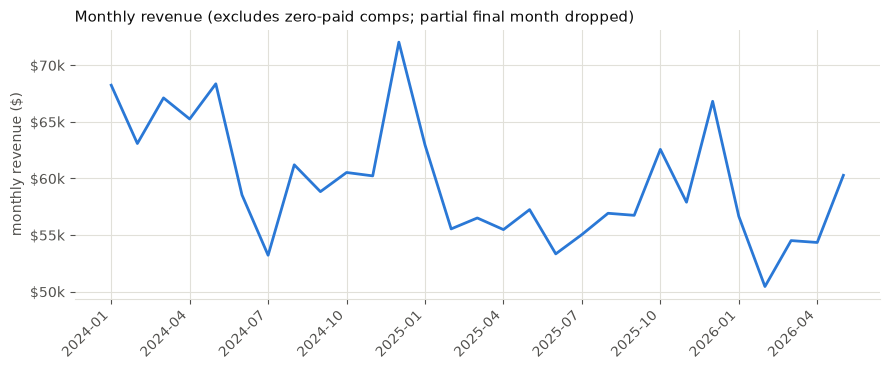

Range: $50,448 to $72,032


In [14]:
revenue_orders = revenue_orders.copy()
revenue_orders["month"] = revenue_orders["checkinTime"].dt.to_period("M")
monthly_revenue = revenue_orders.groupby("month")["paidAmount"].sum()

# drop the final, partial month (fewer than 20 days of data) so it doesn't look like a real drop
last_period = monthly_revenue.index.max()
days_in_last_period = revenue_orders.loc[revenue_orders["month"] == last_period, "checkinTime"].dt.day.max()
if days_in_last_period < 20:
    monthly_revenue = monthly_revenue.iloc[:-1]

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(monthly_revenue.index.astype(str), monthly_revenue.values, color=BLUE, linewidth=2)
ax.set_ylabel("monthly revenue ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1000:.0f}k"))
ax.set_xticks(range(0, len(monthly_revenue), 3))
ax.set_xticklabels([monthly_revenue.index.astype(str)[i] for i in range(0, len(monthly_revenue), 3)], rotation=45, ha="right")
ax.set_title("Monthly revenue (excludes zero-paid comps; partial final month dropped)", loc="left", fontsize=11)
plt.tight_layout()
plt.show()

print(f"Range: ${monthly_revenue.min():,.0f} to ${monthly_revenue.max():,.0f}")


Two things stand out purely descriptively: December is the high point in both full years of data (2024 and 2025), each time noticeably above the surrounding months — consistent with a holiday-season seasonal pattern. And average monthly revenue has drifted down somewhat across the window: ~$63k/month in 2024, ~$58k/month in 2025, ~$55k/month so far in 2026 (full months only, partial June excluded). That's a real, gradual multi-year pattern in this data — not a one-month blip — though this notebook stops at describing it, not diagnosing why.


## New customer acquisition over time

For each customer, their earliest order in this dataset marks their "first-seen" month. Counting how many customers are first-seen in each month gives a rough view of new-customer acquisition — with one important caveat explained right after we look at it.


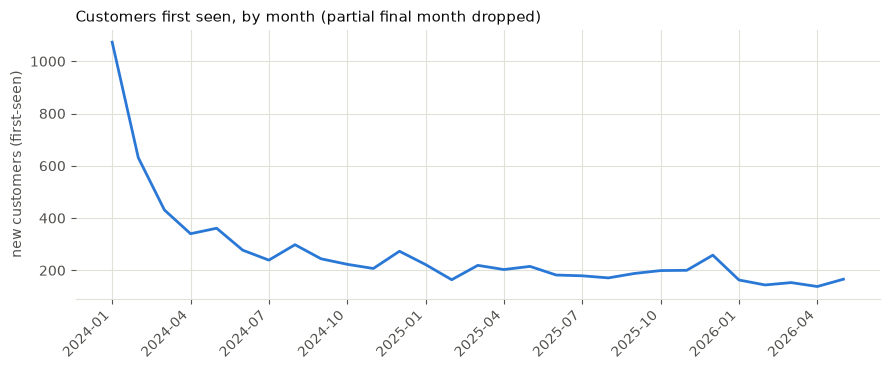

First month (2024-01): 1,073 customers first-seen
All other months, average: 239 customers first-seen


In [15]:
first_seen = customers.groupby("customerID")["checkinTime"].min().dt.to_period("M")
new_customers_by_month = first_seen.value_counts().sort_index()

# same partial-month issue as the revenue chart -- drop it here too so the trend doesn't
# show a fake cliff at the very end
last_period = new_customers_by_month.index.max()
days_in_last_period = customers.loc[
    customers["checkinTime"].dt.to_period("M") == last_period, "checkinTime"
].dt.day.max()
if days_in_last_period < 20:
    new_customers_by_month = new_customers_by_month.iloc[:-1]

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(new_customers_by_month.index.astype(str), new_customers_by_month.values, color=BLUE, linewidth=2)
ax.set_ylabel("new customers (first-seen)")
ax.set_xticks(range(0, len(new_customers_by_month), 3))
ax.set_xticklabels([new_customers_by_month.index.astype(str)[i] for i in range(0, len(new_customers_by_month), 3)],
                    rotation=45, ha="right")
ax.set_title("Customers first seen, by month (partial final month dropped)", loc="left", fontsize=11)
plt.tight_layout()
plt.show()

print(f"First month ({new_customers_by_month.index[0]}): {new_customers_by_month.iloc[0]:,} customers first-seen")
print(f"All other months, average: {new_customers_by_month.iloc[1:].mean():.0f} customers first-seen")


**🚩 Anomaly, not a pattern — and an important one:** the huge January 2024 spike is not a real acquisition surge. January 2024 is the *first month the dataset covers*, so every customer who had ever visited before that point — including long-time regulars — necessarily gets counted as "first-seen" then, simply because there's no earlier data to show their true first visit. This is a classic left-censoring artifact, not evidence Tang suddenly acquired ~1,000 new customers in one month.

Excluding that first month, "new customer" counts settle into a much steadier ~150-300/month range with a gradual decline visible across 2024 into 2025-2026 — but even that softer decline should be read cautiously, since the "first-seen" measure only ever approaches a true new-customer count once we're far enough past the start of the tracked window that most repeat customers have already appeared once.


## One more pattern worth flagging: a large shift in how customers pay

While exploring the data, the split between cash and card payments by year stood out enough to check directly.


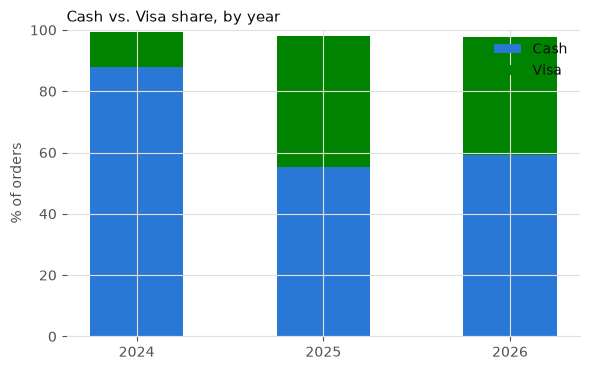

paymentType  Cash  Visa
year                   
2024         87.7  11.6
2025         55.4  42.7
2026         59.3  38.5


In [16]:
orders["year"] = orders["checkinTime"].dt.year
payment_by_year = orders.groupby(["year", "paymentType"]).size().unstack(fill_value=0)
payment_pct = payment_by_year.div(payment_by_year.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(6, 3.8))
years = payment_pct.index.astype(str)
ax.bar(years, payment_pct["Cash"], label="Cash", color=BLUE, width=0.5)
ax.bar(years, payment_pct["Visa"], bottom=payment_pct["Cash"], label="Visa", color=GREEN, width=0.5)

ax.set_ylabel("% of orders")
ax.set_ylim(0, 100)
ax.set_title("Cash vs. Visa share, by year", loc="left", fontsize=11)
ax.legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.show()

print(payment_pct[["Cash", "Visa"]].round(1))


**A genuine, large shift — but flagging some uncertainty about its cause.** Cash share drops from 87.7% (2024) to 55.4% (2025) to 59.3% (2026 year-to-date, partial year), with Visa correspondingly almost quadrupling. That's too large and too consistent to be noise. But a jump this sharp — nearly all in the 2024→2025 transition — is exactly the kind of thing that could also reflect a payment-processing or POS change (a new card terminal, a change in how transactions get logged) rather than a pure shift in customer behavior. This notebook can't distinguish between those two explanations from the order data alone; it's presented as a real pattern in the data, with that caveat attached rather than asserted as "customers switched to cards."


## Summary

**Scope reminder:** all customer-level findings below (visit tiers, revenue concentration) cover the ~71% of orders with a trustworthy customer ID — not all of Tang's business. Time-of-day and revenue-trend findings use the full clean dataset instead.

1. **A small share of customers drives most of the business.** The top tier by visit frequency (12+ visits, ~10% of identified customers) accounts for over half of customer-attributable revenue, while the 56% of customers who've only ordered once account for a much smaller share. This is a fairly typical concentration pattern for a restaurant, but it's stark here: most of the identified customer base has visited exactly once.

2. **Frequent customers aren't bigger spenders — they're just more frequent.** Average ticket size is essentially flat (~$37-39) across every visit-frequency tier, if anything drifting slightly lower for the most frequent visitors. All of the revenue concentration in point 1 comes from visit frequency, not from regulars spending more per meal.

3. **Tang is a dinner restaurant with a real, confirmed Monday closure.** About 72% of orders land in the 4pm-10pm window versus ~21% at lunch, and the near-total absence of Monday orders checks out against the calendar (only a New Year's Day exception and one unexplained single order in ~2.5 years) — a good example of the data matching the known operational reality.

4. **Two "new information" patterns turned out to be measurement artifacts, not real signals** — worth remembering when reading this kind of data in the future. The apparent ~1,000-customer acquisition spike in the dataset's first month is just every existing regular getting counted as "new" because there's no earlier data; and the restaurant's own phone number was quietly the single most "frequent customer" in the raw numbers until it got excluded. Both would have told a misleading story if taken at face value.

**Separately, one real multi-year pattern surfaced that's worth keeping in view:** average monthly revenue has drifted from ~$63k (2024) to ~$58k (2025) to ~$55k (2026 YTD), and cash-vs-card payment mix shifted sharply starting in 2025. Neither is diagnosed here — this notebook only describes what the data shows.

**Open item, not yet resolved:** only one number (Tang's own line) was confirmed and excluded as a non-customer. No other staff/vendor/internal numbers have been checked for — this was a manual, evidence-based call for that one specific value, not a systematic sweep. Worth a manual check later (e.g. against a known list of staff or vendor phone numbers) before treating any "top customer" finding here as fully clean.
